# Stellar scan-rate — final figures

Eight figures comparing **67 / 125 / 200 kDa/s** scan rates under two acquisition
schemes — **GPF** (5 gas-phase 100-Th windows) and **Wide window (WW)** (single
400–900 Th, 3 replicates) — all on the 24-min gradient.

| # | Figure | Source |
|---|--------|--------|
| 1 | Apex total ion count | Skyline `ions` report |
| 2 | LC peak analyte ion count | Skyline `ions` report |
| 3 | Points across the peak | Skyline `ions` report |
| 4 | Actual injection time | mzML scan headers |
| 5 | Actual acquisition rate | mzML scan headers |
| 6 | Acquisition rate vs. injection time | mzML scan headers |
| 7 | Overhead vs. injection time | mzML scan headers |
| 8 | Cycle time vs. injection time | mzML scan headers |

Each figure is followed by a markdown cell documenting exactly how it was
computed and which file it came from. Colour encodes scan rate throughout
(Okabe–Ito, colourblind-safe); scheme is shown by facet (violins) or marker
shape (scatters).

## Method parameters

Read from the mzML scan headers (filter string, isolation-window offsets, scan
windows) for these runs. **AGC target** and the **set** maximum injection time are
instrument-method settings that are *not* written into the mzML: the max IT below
is inferred from the actual injection-time ceiling (every run tops out at 50 ms),
and the AGC target must come from the instrument method.

| Parameter | Value |
|---|---|
| Instrument / analyzer | Thermo Stellar, linear ion trap (ITMS) |
| Acquisition | DIA, 24-min gradient |
| **Scan rate** (the variable) | 67 / 125 / 200 kDa/s |
| MS1 scan range | 350-1250 m/z |
| MS2 scan range | 200-1200 m/z |
| Precursor isolation width | GPF 1.0 Th - Wide window 4.0 Th |
| MS2 windows per cycle | GPF ~100 - Wide window ~125 |
| Fragmentation | HCD, NCE 22 |
| Max injection time | 50 ms *(inferred from the observed IT ceiling; not in mzML)* |
| AGC target | *not stored in the mzML - from the instrument method* |

*Share the instrument method (or the AGC target and set max IT) and I'll replace
the inferred values with the exact settings.*

In [1]:
import re
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns

STELLAR = Path(r"G:/Manuscripts/StellarDIA/ScanRateTest/Stellar")
OUT = Path("output"); OUT.mkdir(exist_ok=True)
FIGDIR = Path("Figures"); FIGDIR.mkdir(exist_ok=True)

# --- style -------------------------------------------------------------------
sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.spines.top": False, "axes.spines.right": False,
    "svg.fonttype": "none",
})

# Okabe-Ito colourblind-safe palette; colour == scan rate everywhere.
RATE_ORDER = ["67SR", "125SR", "200SR"]
RATE_LABEL = {"67SR": "67 kDa/s", "125SR": "125 kDa/s", "200SR": "200 kDa/s"}
RATE_COLOR = {"67SR": "#0072B2", "125SR": "#E69F00", "200SR": "#009E73"}
SCHEME_ORDER = ["GPF", "WW"]
SCHEME_LABEL = {"GPF": "GPF", "WW": "Wide window"}
SCHEME_MARKER = {"GPF": "o", "WW": "^"}


def save_fig(fig, name):
    fig.savefig(FIGDIR / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGDIR / f"{name}.svg", bbox_inches="tight")
    return fig


# --- the six runs: scan rate x scheme ---------------------------------------
RUNS = [
    dict(rate="67SR",  scheme="GPF", ions=STELLAR/"24m_67SR/reports/24min_67SR_GPF_ions.parquet",   mzml_dir=STELLAR/"24m_67SR"),
    dict(rate="125SR", scheme="GPF", ions=STELLAR/"24min_125SR/report/24min_125SR_GPF_ions.parquet", mzml_dir=STELLAR/"24min_125SR"),
    dict(rate="200SR", scheme="GPF", ions=STELLAR/"24min_200SR/reports/24min_200SR_GPF_ions.parquet", mzml_dir=STELLAR/"24min_200SR"),
    dict(rate="67SR",  scheme="WW",  ions=STELLAR/"WideWindow_67SR/reports/WW_67SR_ions.parquet",     mzml_dir=STELLAR/"WideWindow_67SR"),
    dict(rate="125SR", scheme="WW",  ions=STELLAR/"WideWindow_125SR/reports/125SR_WW_ions.parquet",   mzml_dir=STELLAR/"WideWindow_125SR"),
    dict(rate="200SR", scheme="WW",  ions=STELLAR/"WideWindow_200SR/reports/200SR_WW_ions.parquet",   mzml_dir=STELLAR/"WideWindow_200SR"),
]
print(f"{len(RUNS)} runs configured")

6 runs configured


## Load the Skyline `ions` reports (figures 1–3)

One `ions` report per run (Skyline → parquet). Columns used:
`ApexTotalIonCountFragment`, `LcPeakAnalyteIonCountFragment`, `PointsAcrossPeak`.

- **GPF**: each of the 5 gas-phase windows is a separate `ReplicateName`; a
  precursor contributes one row per window in which it was measured. Rows where
  the metric is missing (precursor not in that window's m/z range) are dropped.
- **WW**: three technical replicates (TR1–3) per precursor; these are **averaged**
  per precursor before plotting (matching the earlier violin analysis).

In [2]:
CANON = {
    "replicatename": "ReplicateName",
    "precursor": "Precursor",
    "peptide": "Peptide",
    "apextotalioncountfragment": "ApexTotalIonCountFragment",
    "lcpeakanalyteioncountfragment": "LcPeakAnalyteIonCountFragment",
    "pointsacrosspeak": "PointsAcrossPeak",
}
ION_COLS = ["ApexTotalIonCountFragment", "LcPeakAnalyteIonCountFragment", "PointsAcrossPeak"]

def _canon(name):
    return re.sub(r"[^a-z0-9]", "", name.lower())

def load_ions(run):
    # Reports vary in column naming (camelCase vs Underscore_Case); normalize.
    df = pd.read_parquet(run["ions"])
    df = df.rename(columns={c: CANON[_canon(c)] for c in df.columns if _canon(c) in CANON})
    df = df[["ReplicateName", "Precursor", "Peptide"] + ION_COLS]
    if run["scheme"] == "WW":
        # average the 3 technical replicates per precursor
        df = df.groupby(["Precursor", "Peptide"], as_index=False)[ION_COLS].mean()
    return df.assign(rate=run["rate"], scheme=run["scheme"])

ions = pd.concat([load_ions(r) for r in RUNS], ignore_index=True)
ions["rate"] = pd.Categorical(ions["rate"], RATE_ORDER, ordered=True)
ions["scheme"] = pd.Categorical(ions["scheme"], SCHEME_ORDER, ordered=True)
print(ions.shape)
ions.groupby(["scheme", "rate"], observed=True)[ION_COLS].apply(
    lambda g: pd.Series({c: int((g[c] > 0).sum()) for c in ION_COLS})
)

(1389862, 8)


ApexTotalIonCountFragment  LcPeakAnalyteIonCountFragment  \
scheme rate                                                              
GPF    67SR                      220213                         168035   
       125SR                     303163                         303163   
       200SR                     334250                         334250   
WW     67SR                       20064                          20064   
       125SR                      17766                          17766   
       200SR                       4334                           4334   

              PointsAcrossPeak  
scheme rate                     
GPF    67SR             225611  
       125SR            476399  
       200SR            525249  
WW     67SR              20064  
       125SR             17766  
       200SR              4334

In [3]:
def violin_by_rate(data, valuecol, ylabel, name, log=True, floor_positive=True, annotate_n=False):
    """Violin+box of a per-precursor metric, x=scan rate, faceted GPF | WW."""
    d = data[["rate", "scheme", valuecol]].dropna(subset=[valuecol]).copy()
    if floor_positive:
        d = d[d[valuecol] > 0]
    d["y"] = np.log10(d[valuecol]) if log else d[valuecol]
    fig, axes = plt.subplots(1, 2, figsize=(8, 4.2), sharey=True)
    for ax, scheme in zip(axes, SCHEME_ORDER):
        sub = d[d["scheme"] == scheme]
        sns.violinplot(
            data=sub, x="rate", y="y", order=RATE_ORDER, hue="rate", hue_order=RATE_ORDER,
            palette=RATE_COLOR, density_norm="width", cut=0, inner=None, dodge=False,
            linewidth=0.7, legend=False, ax=ax,
        )
        for coll in ax.collections:
            coll.set_alpha(0.65)
        sns.boxplot(
            data=sub, x="rate", y="y", order=RATE_ORDER, width=0.13, showfliers=False,
            boxprops=dict(facecolor="white", edgecolor="black", linewidth=0.5),
            whiskerprops=dict(linewidth=0.5), capprops=dict(linewidth=0.5),
            medianprops=dict(linewidth=0.7, color="black"), ax=ax,
        )
        if annotate_n:
            counts = sub.groupby("rate", observed=True).size().reindex(RATE_ORDER, fill_value=0)
            for j, r in enumerate(RATE_ORDER):
                ax.text(j, 0.01, f"n={int(counts[r]):,}", transform=ax.get_xaxis_transform(),
                        ha="center", va="bottom", fontsize=7.5, color="0.25")
        ax.set_title(SCHEME_LABEL[scheme])
        ax.set_xlabel("")
        ax.set_xticks(range(len(RATE_ORDER)))
        ax.set_xticklabels([RATE_LABEL[r] for r in RATE_ORDER], rotation=20, ha="right")
        if log:
            ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _p: f"{10**v:,.0f}"))
    axes[0].set_ylabel(ylabel)
    axes[1].set_ylabel("")
    fig.tight_layout()
    save_fig(fig, name)
    return fig

## Figure 1 — Apex total ion count
- **n (below each violin):** number of precursor measurements with value > 0 contributing to that distribution - GPF = precursor x gas-phase window; WW = per-precursor (averaged over TR1-3).

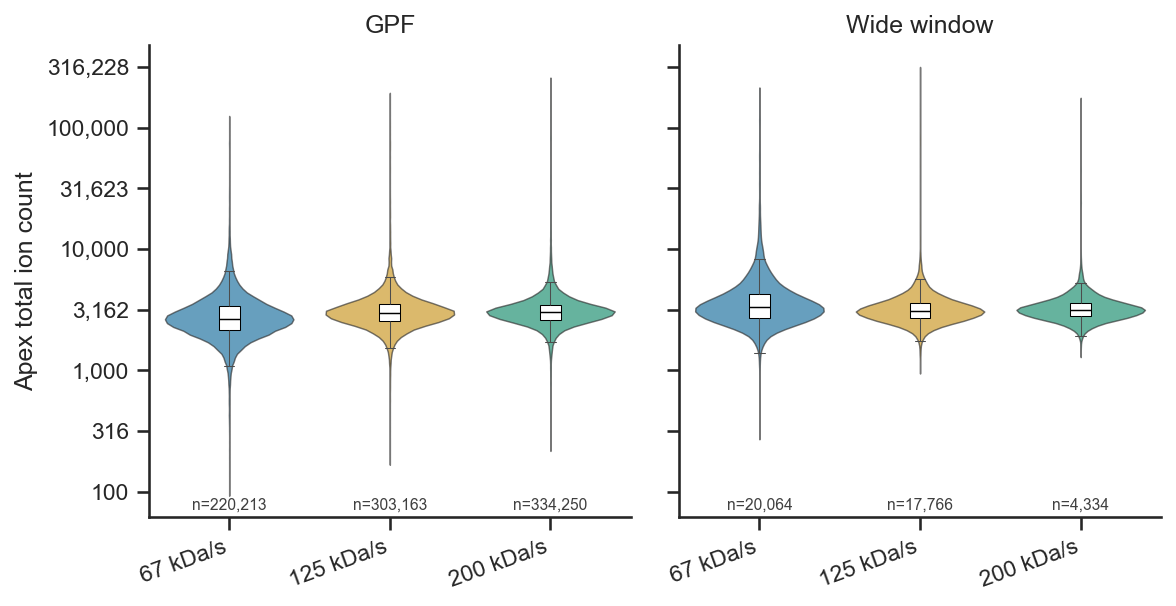

In [4]:
violin_by_rate(ions, "ApexTotalIonCountFragment",
               "Apex total ion count", "fig1_apex_total_ion_count", log=True,
               annotate_n=True)
plt.show()

**Figure 1 — Apex total ion count.**

- **Source:** Skyline `ions` report (per run), column `ApexTotalIonCountFragment`
  — the total ion count (all ions in the isolation window, target + background)
  in the single apex spectrum of each precursor's chromatographic peak.
- **Calculation:** one value per precursor measurement. For GPF, per
  precursor × gas-phase window; for WW, averaged across the 3 technical
  replicates. Non-detected rows (missing value) and values ≤ 0 are dropped.
- **Display:** width-scaled violin + box on a log10 axis; x = scan rate,
  faceted GPF vs Wide window.

## Figure 2 — LC peak analyte ion count

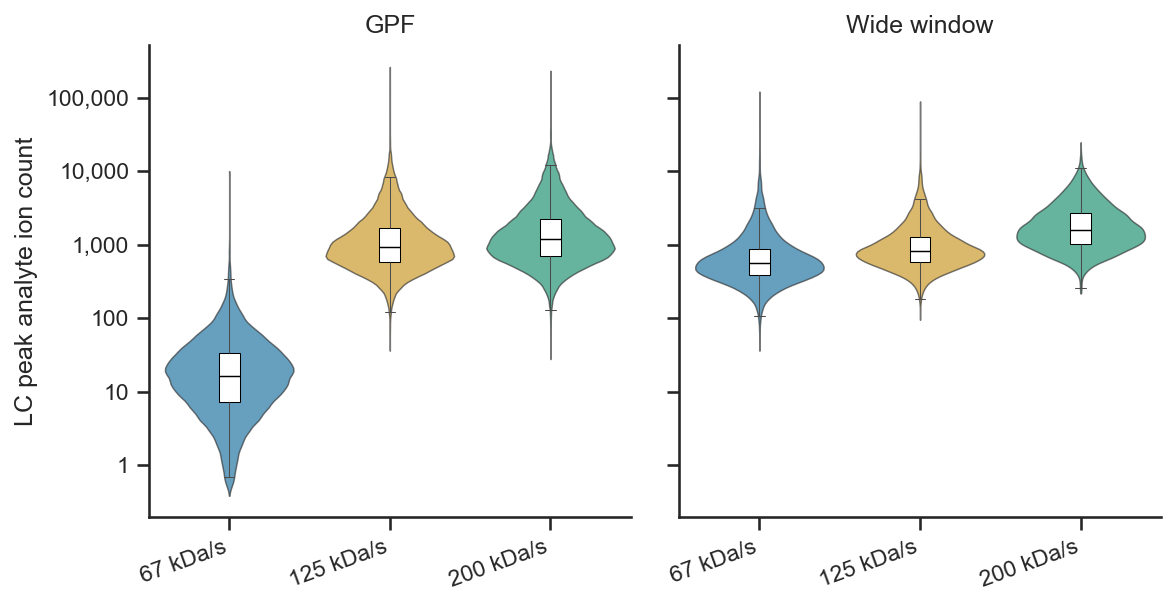

In [5]:
violin_by_rate(ions, "LcPeakAnalyteIonCountFragment",
               "LC peak analyte ion count", "fig2_lc_peak_analyte_ion_count", log=True)
plt.show()

**Figure 2 — LC peak analyte ion count.**

- **Source:** Skyline `ions` report, column `LcPeakAnalyteIonCountFragment` —
  the analyte (target-transition) ion count integrated over the whole LC peak,
  i.e. ions attributable to the peptide rather than to background/chimera.
- **Calculation:** identical handling to Figure 1 (per-precursor; GPF per window,
  WW averaged over TR1–3; values ≤ 0 dropped).
- **Display:** width-scaled violin + box, log10 axis, faceted by scheme.
- **Note:** the *analyte* column was chosen (not `LcPeakTotalIonCountFragment`)
  to match the earlier violin analysis; swap the column name to switch to total.

**Figure 3 - Points across the peak.**

- **Source:** Skyline *Points across the peak* report (one per run), column
  `PointsAcrossPeak` - the number of MS/MS scans within each peptide's integrated
  chromatographic peak. All six runs now have this report (including WW 125SR).
- **Calculation:** peptide-level; GPF keeps per peptide x gas-phase window rows,
  WW averages over TR1-3 per peptide; values <= 0 dropped.
- **Display:** width-scaled violin + box on a **linear** axis, faceted by scheme.
  Higher scan rate -> more points across the peak.

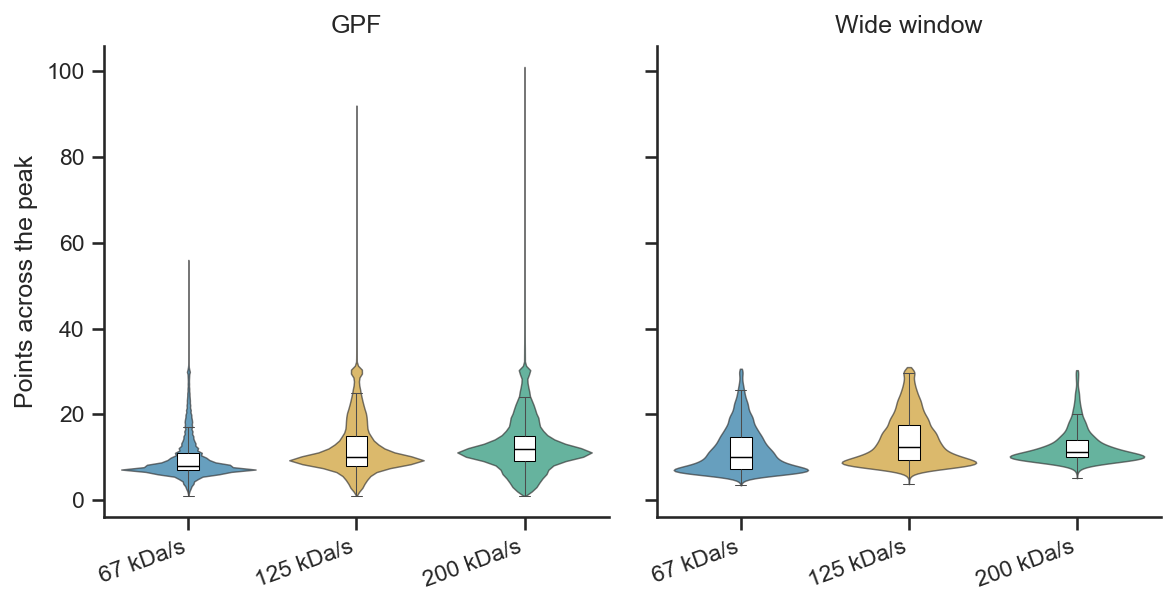

In [6]:
POINTS = {
    ("67SR",  "GPF"): STELLAR / "24m_67SR/reports/24min_67SR_GPF_Points across the peak.parquet",
    ("125SR", "GPF"): STELLAR / "24min_125SR/report/24min_125SR_GPF_pointsAcrossPeak.parquet",
    ("200SR", "GPF"): STELLAR / "24min_200SR/reports/24min_200SR_GPF_Points across the peak.parquet",
    ("67SR",  "WW"):  STELLAR / "WideWindow_67SR/reports/WW_67SR_Points across the peak.parquet",
    ("125SR", "WW"):  STELLAR / "WideWindow_125SR/reports/125SR_WW_PointsAcrossPeak.parquet",
    ("200SR", "WW"):  STELLAR / "WideWindow_200SR/reports/200SR_WW_Points across the peak.parquet",
}

def load_points(rate, scheme, path):
    df = pd.read_parquet(path)
    df = df.rename(columns={c: CANON[_canon(c)] for c in df.columns if _canon(c) in CANON})
    df = df[["Peptide", "PointsAcrossPeak"]].dropna(subset=["PointsAcrossPeak"])
    if scheme == "WW":  # average the 3 technical replicates per peptide
        df = df.groupby("Peptide", as_index=False)["PointsAcrossPeak"].mean()
    return df.assign(rate=rate, scheme=scheme)

points = pd.concat([load_points(r, s, pth) for (r, s), pth in POINTS.items()], ignore_index=True)
points["rate"] = pd.Categorical(points["rate"], RATE_ORDER, ordered=True)
points["scheme"] = pd.Categorical(points["scheme"], SCHEME_ORDER, ordered=True)
violin_by_rate(points, "PointsAcrossPeak", "Points across the peak",
               "fig3_points_across_peak", log=False)
plt.show()

**Figure 3 — Points across the peak.**

- **Source:** Skyline `ions` report, column `PointsAcrossPeak` — the number of
  MS/MS scans (measurement points) that fall within each precursor's integrated
  chromatographic peak. (The same value is available in the dedicated
  *Points across the peak* report; the `ions` report is used here so all six
  runs share one source, since WW 125SR has no separate points report.)
- **Calculation:** per-precursor; GPF per window, WW averaged over TR1–3;
  values ≤ 0 dropped. Higher scan rate → more points across the peak.
- **Display:** width-scaled violin + box on a **linear** axis (counts are small
  integers), faceted by scheme.

## Extract mzML scan-timing metrics (figures 4–8)

Streams each of the 24 mzML files (all 6 runs) reading only scan headers — no
peak decoding. Cached to `output/` so it only parses once. Per MS2 scan it reads
retention time, ion injection time (`MS:1000927`), and precursor m/z; it also
counts **every** spectrum for the acquisition-rate denominator.

In [7]:
def _strip_ns(tag):
    return tag.rsplit("}", 1)[-1]

def parse_mzml(path):
    """Return per-file counts/RT span and per-MS2 arrays (rt_s, prec_mz, inj_ms)."""
    n_total = 0
    rt_min, rt_max = np.inf, -np.inf
    ms2_rt, ms2_pmz, ms2_inj = [], [], []
    ms_level = rt = inj = sel = iso = None
    in_spec = False
    ctx = ET.iterparse(str(path), events=("start", "end"))
    _, root = next(ctx)
    for ev, el in ctx:
        tag = _strip_ns(el.tag)
        if ev == "start":
            if tag == "spectrum":
                in_spec = True
                ms_level = rt = inj = sel = iso = None
            continue
        if not in_spec:
            if tag == "spectrum":
                root.clear()
            continue
        if tag == "cvParam":
            acc = el.get("accession")
            if acc == "MS:1000511":
                ms_level = int(el.get("value"))
            elif acc == "MS:1000016":
                v = float(el.get("value"))
                rt = v * 60.0 if el.get("unitAccession") == "UO:0000031" else v
            elif acc == "MS:1000927":
                inj = float(el.get("value"))
            elif acc == "MS:1000744":
                sel = float(el.get("value"))
            elif acc == "MS:1000827":
                iso = float(el.get("value"))
        elif tag == "spectrum":
            n_total += 1
            if rt is not None:
                rt_min = min(rt_min, rt); rt_max = max(rt_max, rt)
            if ms_level == 2:
                ms2_rt.append(rt); ms2_inj.append(inj)
                ms2_pmz.append(sel if sel is not None else iso)
            in_spec = False
            el.clear(); root.clear()
    return (n_total, rt_min, rt_max,
            np.array(ms2_rt, float), np.array(ms2_pmz, float), np.array(ms2_inj, float))


def file_metrics(path, rate, scheme):
    n_total, rt_min, rt_max, rt, pmz, inj = parse_mzml(path)
    n_ms2 = len(rt)
    total_time = rt_max - rt_min                      # seconds
    acq_rate = n_total / total_time                   # total spectra / total time (Hz)
    mean_it = np.nanmean(inj)                          # actual injection time (ms)
    time_per_ms2 = 1000.0 * total_time / n_ms2         # ms per MS/MS scan
    overhead = time_per_ms2 - mean_it                  # ms
    order = np.argsort(rt)
    pmz_o, rt_o = pmz[order], rt[order]
    resets = np.where(np.diff(pmz_o) < 0)[0] + 1       # precursor m/z reset = new cycle
    cycle_time = float(np.mean(np.diff(rt_o[resets]))) if len(resets) > 1 else np.nan
    return dict(
        filename=path.name, rate=rate, scheme=scheme,
        n_total_spectra=n_total, n_ms2=n_ms2, total_time_s=total_time,
        acq_rate_hz=acq_rate, mean_injection_ms=mean_it,
        time_per_ms2_ms=time_per_ms2, overhead_ms=overhead, cycle_time_s=cycle_time,
    ), inj


timing_csv = OUT / "timing_metrics.csv"
it_parquet = OUT / "injection_time_scans.parquet"
IT_CAP = 30_000  # per-file cap on injection-time scans kept for the fig-4 violin

if timing_csv.exists() and it_parquet.exists():
    timing = pd.read_csv(timing_csv)
    it_scans = pd.read_parquet(it_parquet)
else:
    rows, it_parts = [], []
    rng = np.random.default_rng(0)
    for run in RUNS:
        for f in sorted(run["mzml_dir"].glob("*.mzML")):
            m, inj = file_metrics(f, run["rate"], run["scheme"])
            rows.append(m)
            inj = inj[np.isfinite(inj) & (inj > 0)]
            if len(inj) > IT_CAP:
                inj = rng.choice(inj, IT_CAP, replace=False)
            it_parts.append(pd.DataFrame({"inj_ms": inj, "rate": run["rate"], "scheme": run["scheme"]}))
            print(f"{run['rate']:>5} {run['scheme']:<3} {f.name}: "
                  f"{m['acq_rate_hz']:.1f} Hz, IT {m['mean_injection_ms']:.2f} ms, "
                  f"overhead {m['overhead_ms']:.2f} ms", flush=True)
    timing = pd.DataFrame(rows)
    it_scans = pd.concat(it_parts, ignore_index=True)
    timing.to_csv(timing_csv, index=False)
    it_scans.to_parquet(it_parquet, index=False)

for df in (timing, it_scans):
    df["rate"] = pd.Categorical(df["rate"], RATE_ORDER, ordered=True)
    df["scheme"] = pd.Categorical(df["scheme"], SCHEME_ORDER, ordered=True)
timing.round(2)

,filename,rate,scheme,n_total_spectra,n_ms2,total_time_s,acq_rate_hz,mean_injection_ms,time_per_ms2_ms,overhead_ms,cycle_time_s
0,400to500_24m_run94_67SR.mzML,67SR,GPF,63933,63300,1443.27,44.30,10.56,22.80,12.24,2.27
1,500to600_24m_run94_67SR.mzML,67SR,GPF,64842,64200,1440.64,45.01,9.14,22.44,13.30,2.24
2,600to700_24m_run94_67SR.mzML,67SR,GPF,62519,61900,1443.71,43.30,11.68,23.32,11.65,2.32
3,700to800_24m_run94_67SR_20260525100555.mzML,67SR,GPF,57974,57400,1441.28,40.22,16.45,25.11,8.66,2.50
4,800to900_24m_run94_67SR.mzML,67SR,GPF,48783,48300,1442.14,33.83,24.05,29.86,5.81,2.98
5,400to500_24m_run94_125SR.mzML,125SR,GPF,87870,87000,1442.88,60.90,9.04,16.58,7.54,1.65
6,500to600_24m_run94_125SR.mzML,125SR,GPF,92415,91500,1443.95,64.00,7.94,15.78,7.84,1.57
7,600to700_24m_run94_125SR.mzML,125SR,GPF,86254,85400,1443.53,59.75,10.27,16.90,6.63,1.68
8,700to800_24m_run94_125SR.mzML,125SR,GPF,74134,73400,1441.55,51.43,14.82,19.64,4.82,1.96
9,800to900_24m_run94_125SR.mzML,125SR,GPF,56055,55500,1445.15,38.79,22.85,26.04,3.19,2.59


## Figure 4 — Actual injection time
- **Axis:** log10, zoomed to 0.2-60 ms so the body of the distribution is legible; the sparse sub-0.2 ms tail (near-instant AGC fills) is outside the view. The 50 ms method ceiling is visible at the top.

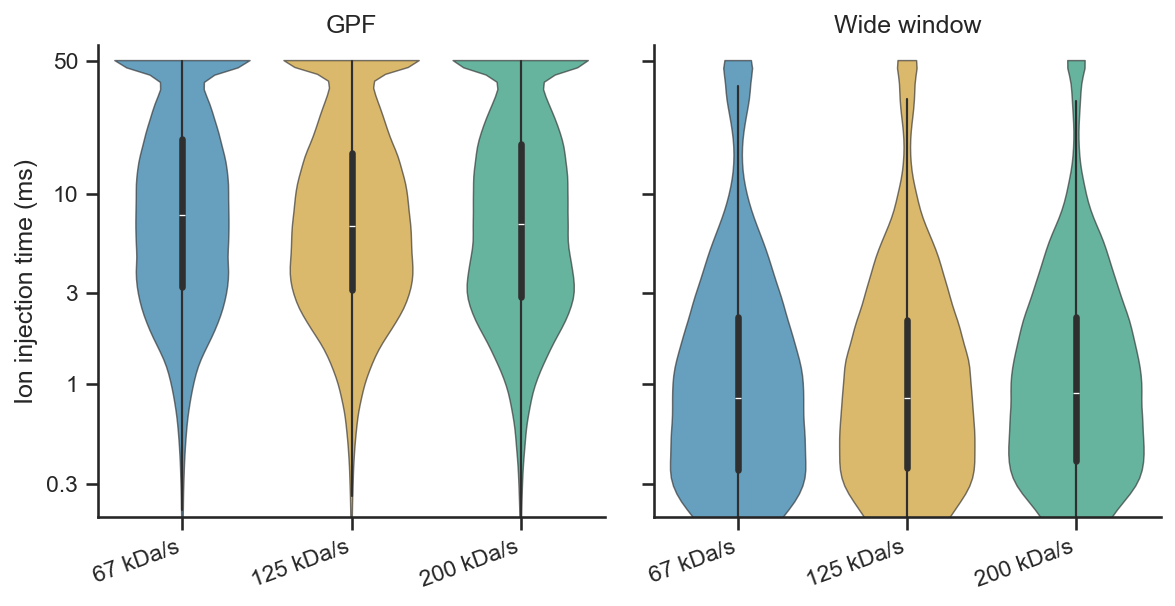

In [8]:
d = it_scans.copy()
d["y"] = np.log10(d["inj_ms"])
YTICKS = [0.3, 1, 3, 10, 50]  # focus on where injection time actually sits
fig, axes = plt.subplots(1, 2, figsize=(8, 4.2), sharey=True)
for ax, scheme in zip(axes, SCHEME_ORDER):
    sub = d[d["scheme"] == scheme]
    sns.violinplot(data=sub, x="rate", y="y", order=RATE_ORDER, hue="rate",
                   hue_order=RATE_ORDER, palette=RATE_COLOR, density_norm="width",
                   cut=0, inner="box", linewidth=0.7, dodge=False, legend=False, ax=ax)
    for coll in ax.collections:
        coll.set_alpha(0.65)
    ax.set_title(SCHEME_LABEL[scheme]); ax.set_xlabel("")
    ax.set_xticks(range(len(RATE_ORDER)))
    ax.set_xticklabels([RATE_LABEL[r] for r in RATE_ORDER], rotation=20, ha="right")
    ax.set_ylim(np.log10(0.2), np.log10(60))
    ax.set_yticks([np.log10(v) for v in YTICKS])
    ax.set_yticklabels([f"{v:g}" for v in YTICKS])
axes[0].set_ylabel("Ion injection time (ms)"); axes[1].set_ylabel("")
fig.tight_layout(); save_fig(fig, "fig4_actual_injection_time"); plt.show()

**Figure 4 — Actual injection time.**

- **Source:** mzML scan headers, `ion injection time` (`MS:1000927`), read from
  every MS2 spectrum of all 24 mzML files.
- **Calculation:** the *actual* per-scan injection time the instrument used
  (AGC-driven, capped at the 50 ms method maximum). Distribution over all MS2
  scans, subsampled to ≤ 30 000 scans per run for the density estimate; scans
  with IT ≤ 0 dropped.
- **Display:** width-scaled violin (inner box = quartiles) on a log10 axis;
  x = scan rate, faceted by scheme.

**Figure 5 - Actual acquisition rate.**

- **Source:** mzML scan headers (all 24 files).
- **Calculation:** `acquisition rate (Hz) = total spectra in the mzML / total
  acquisition time` (last - first spectrum RT, s). Total spectra include MS1 + MS2
  (MS1 ~ 1%). One point per mzML file. Black dash = mean.
- **Colour:** in the **GPF** facet, points are coloured by **m/z window** (cividis,
  400-500 -> 800-900); higher-m/z windows need longer injection times and so run at
  a lower rate. The **Wide window** facet is a single 400-900 window, so its 3
  replicate points share one neutral colour.
- **Display:** x = scan rate, faceted by scheme.

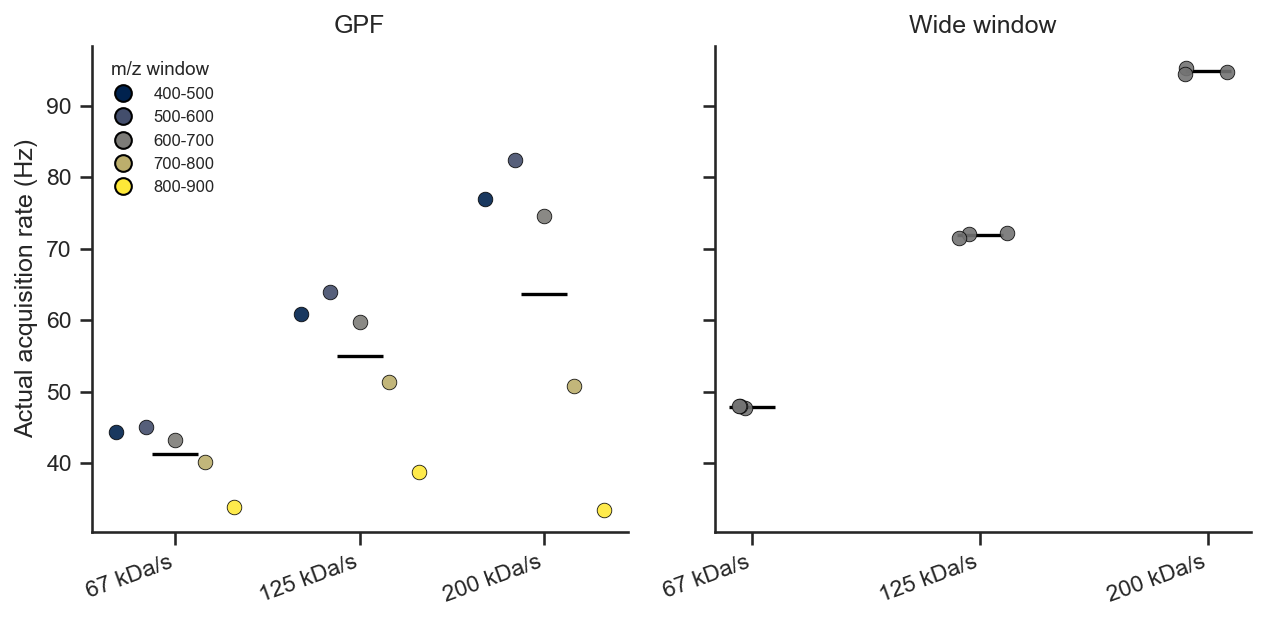

In [9]:
import matplotlib.cm as cm
WINDOWS = ["400-500", "500-600", "600-700", "700-800", "800-900"]
WCOLOR = {w: cm.cividis(k / (len(WINDOWS) - 1)) for k, w in enumerate(WINDOWS)}

def _window(fn):
    m = re.search(r"(\d{3})to(\d{3})", fn)
    a, b = int(m.group(1)), int(m.group(2))
    return "Wide window" if (a, b) == (400, 900) else f"{a}-{b}"

t5 = timing.copy()
t5["window"] = t5["filename"].map(_window)

fig, axes = plt.subplots(1, 2, figsize=(8.6, 4.3), sharey=True)
g = t5[t5["scheme"] == "GPF"]
sns.stripplot(data=g, x="rate", y="acq_rate_hz", order=RATE_ORDER, hue="window",
              hue_order=WINDOWS, palette=WCOLOR, dodge=True, size=7, alpha=0.9,
              edgecolor="black", linewidth=0.4, legend=False, ax=axes[0])
gm = g.groupby("rate", observed=True)["acq_rate_hz"].mean().reindex(RATE_ORDER)
axes[0].plot(range(len(RATE_ORDER)), gm.values, "_", color="black", markersize=22, markeredgewidth=1.6)
axes[0].set_title("GPF")
w = t5[t5["scheme"] == "WW"]
sns.stripplot(data=w, x="rate", y="acq_rate_hz", order=RATE_ORDER, color="0.45",
              size=7, alpha=0.9, edgecolor="black", linewidth=0.4, jitter=0.12, ax=axes[1])
wm = w.groupby("rate", observed=True)["acq_rate_hz"].mean().reindex(RATE_ORDER)
axes[1].plot(range(len(RATE_ORDER)), wm.values, "_", color="black", markersize=22, markeredgewidth=1.6)
axes[1].set_title("Wide window")
for ax in axes:
    ax.set_xlabel(""); ax.set_xticks(range(len(RATE_ORDER)))
    ax.set_xticklabels([RATE_LABEL[r] for r in RATE_ORDER], rotation=20, ha="right")
axes[0].set_ylabel("Actual acquisition rate (Hz)"); axes[1].set_ylabel("")
wh = [Line2D([0], [0], marker="o", linestyle="", markerfacecolor=WCOLOR[wn],
             markeredgecolor="black", markersize=8, label=wn) for wn in WINDOWS]
axes[0].legend(handles=wh, title="m/z window", loc="upper left", frameon=False,
               fontsize=8, title_fontsize=9)
fig.tight_layout(); save_fig(fig, "fig5_actual_acquisition_rate"); plt.show()

**Figure 5 — Actual acquisition rate.**

- **Source:** mzML scan headers (all 24 files).
- **Calculation:** `acquisition rate (Hz) = total number of spectra in the mzML
  ÷ total acquisition time`, where total acquisition time = (retention time of
  the last spectrum − retention time of the first spectrum), in seconds. Total
  spectra include MS1 + MS2 (MS1 is ~1 % of scans here). One point per mzML file
  — for GPF, the 5 gas-phase windows; for WW, the 3 technical replicates. Black
  dash = mean.
- **Display:** per-file points, x = scan rate, faceted by scheme.

In [10]:
def scatter_vs_it(ycol, ylabel, name, ylog=False):
    fig, ax = plt.subplots(figsize=(6.2, 4.6))
    for rate in RATE_ORDER:
        for scheme in SCHEME_ORDER:
            sub = timing[(timing["rate"] == rate) & (timing["scheme"] == scheme)]
            ax.scatter(sub["mean_injection_ms"], sub[ycol],
                       c=RATE_COLOR[rate], marker=SCHEME_MARKER[scheme],
                       s=70, alpha=0.85, edgecolor="black", linewidth=0.4)
    ax.set_xlabel("Actual injection time (ms)"); ax.set_ylabel(ylabel)
    if ylog:
        ax.set_yscale("log")
    rate_h = [Line2D([0], [0], marker="s", linestyle="", markerfacecolor=RATE_COLOR[r],
                     markeredgecolor="none", markersize=9, label=RATE_LABEL[r]) for r in RATE_ORDER]
    scheme_h = [Line2D([0], [0], marker=SCHEME_MARKER[s], linestyle="", markerfacecolor="0.4",
                       markeredgecolor="black", markersize=9, label=SCHEME_LABEL[s]) for s in SCHEME_ORDER]
    leg1 = ax.legend(handles=rate_h, title="Scan rate", loc="upper left",
                     bbox_to_anchor=(1.02, 1.0), frameon=False)
    ax.add_artist(leg1)
    ax.legend(handles=scheme_h, title="Scheme", loc="upper left",
              bbox_to_anchor=(1.02, 0.55), frameon=False)
    fig.tight_layout(); save_fig(fig, name); return fig

## Figure 6 — Actual acquisition rate vs. actual injection time

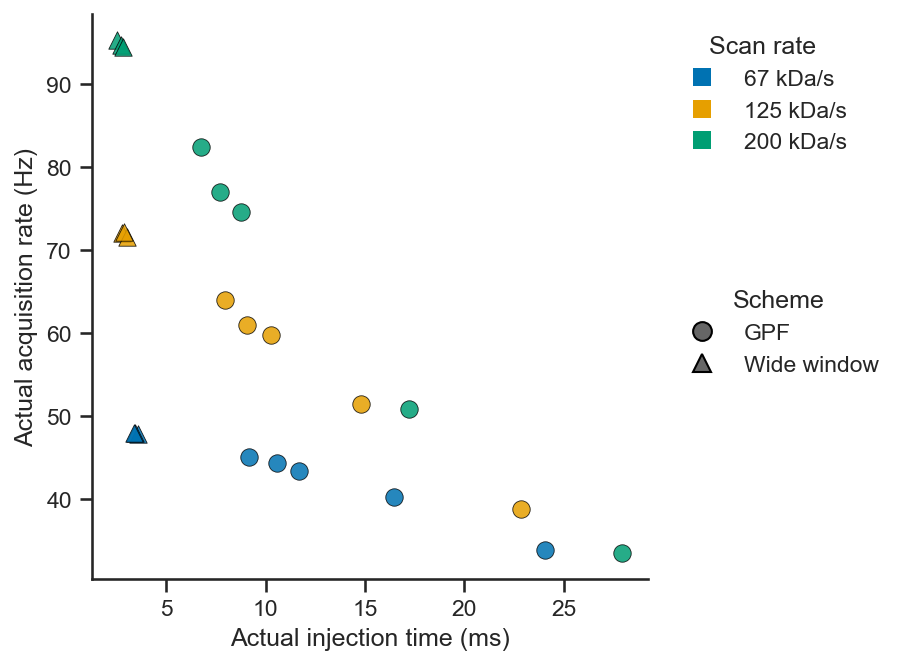

In [11]:
scatter_vs_it("acq_rate_hz", "Actual acquisition rate (Hz)", "fig6_acqrate_vs_injection")
plt.show()

**Figure 6 — Acquisition rate vs. injection time.**

- **Source:** mzML scan headers; one point per mzML file (24 total).
- **Axes:** x = mean actual injection time per file (`MS:1000927`); y = actual
  acquisition rate (total spectra ÷ total time, as in Figure 5).
- **Encoding:** colour = scan rate; marker = scheme (● GPF, ▲ Wide window).
- **Reading it:** longer injection times (higher-m/z GPF windows) force lower
  acquisition rates; the WW points sit at short IT / high rate.

## Figure 7 — Overhead vs. actual injection time

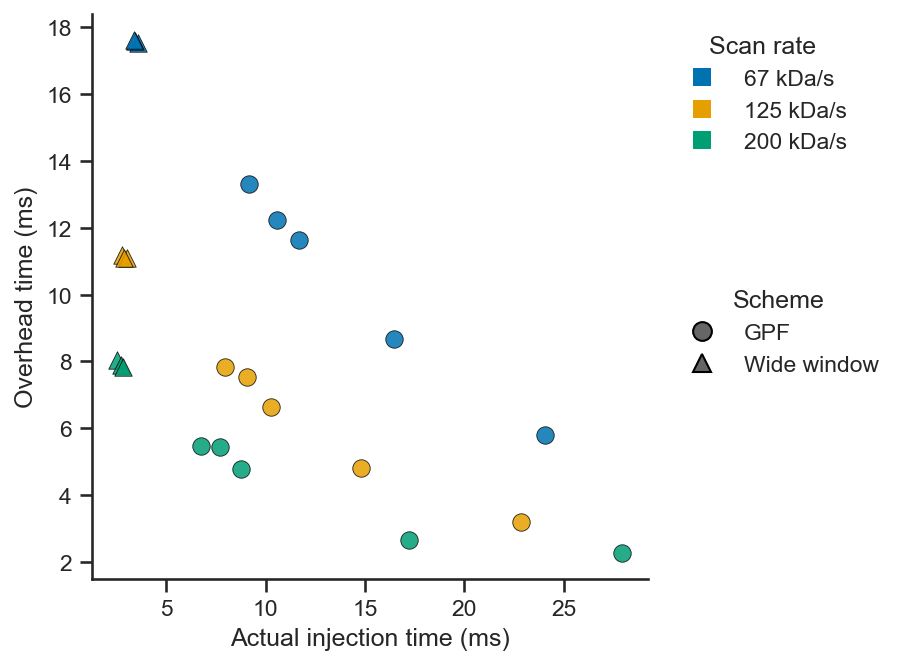

In [12]:
scatter_vs_it("overhead_ms", "Overhead time (ms)", "fig7_overhead_vs_injection")
plt.show()

**Figure 7 — Overhead vs. injection time.**

- **Source:** mzML scan headers; one point per mzML file.
- **Calculation:** `overhead (ms) = average time per MS/MS scan − actual mean
  injection time`, where average time per MS/MS scan = 1000 × total acquisition
  time ÷ number of MS2 scans. This is the per-scan time **not** spent injecting
  ions (isolation, activation, scan-out, electronics).
- **Note on the subtrahend:** the method's *set* max injection time is 50 ms for
  every run (so `time_per_scan − 50 ms` would be negative and meaningless); the
  **actual mean** injection time per file is used instead, per the analysis
  decision, giving the standard `time_per_scan = injection + overhead`
  decomposition.
- **Encoding:** colour = scan rate; marker = scheme. Overhead is expected to be
  roughly flat across injection time and lower at higher scan rate (faster
  scan-out).

## Figure 8 — Cycle time vs. actual injection time

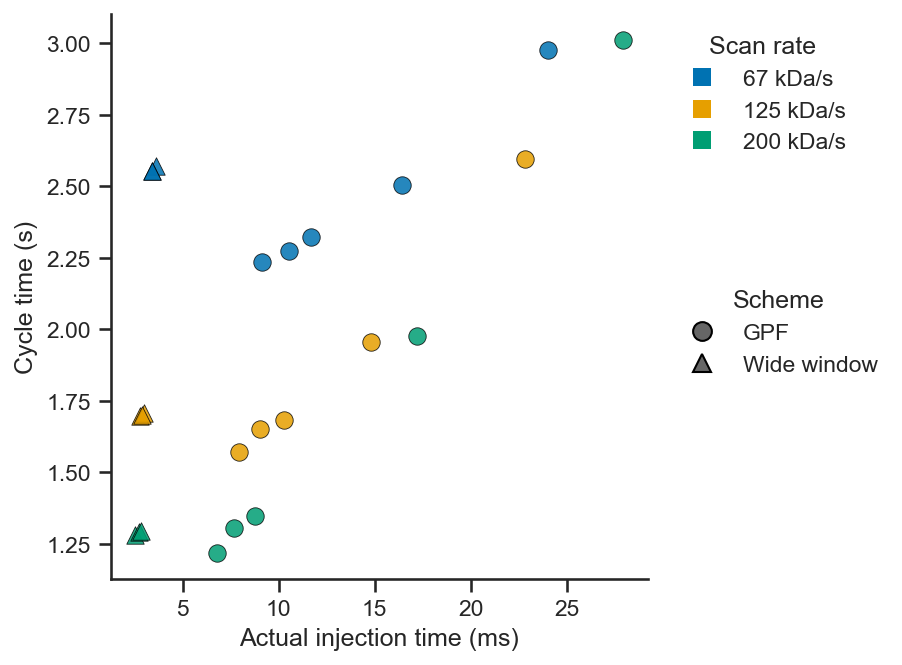

In [13]:
scatter_vs_it("cycle_time_s", "Cycle time (s)", "fig8_cycletime_vs_injection")
plt.show()

**Figure 8 — Cycle time vs. injection time.**

- **Source:** mzML scan headers; one point per mzML file.
- **Calculation:** cycle time = mean retention-time difference between the starts
  of consecutive DIA cycles. A cycle boundary is detected where the precursor
  m/z steps **down** (`Δ precursor m/z < 0`) as the schedule resets from the top
  of the window range back to the bottom; cycle time = mean of the differences
  between successive reset retention times.
- **Axes / encoding:** x = mean actual injection time per file; colour = scan
  rate; marker = scheme. Longer injection times lengthen the cycle.
- **Cross-check:** Skyline's *Points across the peak* report also reports a
  `CycleTimeAcrossPeak` per precursor; the mzML-derived value here is the
  whole-run mean and is the definition requested.

## Session info

In [14]:
import sys, matplotlib
for n, m in [("python", sys.version.split()[0]), ("pandas", pd.__version__),
             ("numpy", np.__version__), ("seaborn", sns.__version__),
             ("matplotlib", matplotlib.__version__)]:
    print(f"{n:11s} {m}")

python      3.11.15
pandas      3.0.2
numpy       2.4.4
seaborn     0.13.2
matplotlib  3.10.9
